**Import required libraries**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

**Upload the feature dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving master_features.csv to master_features.csv


**Load the feature dataset**

In [ ]:
features = pd.read_csv("master_features.csv")

print(features.shape)
features.head()

(8622, 2055)


,Label,MolecularWeight,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,FP_0,FP_1,FP_2,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,1,286.239,1.59282,4,6,115.06,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,154.253,2.50370,1,1,20.23,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,230.310,5.02060,0,0,0.00,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,108.140,1.70062,1,1,20.23,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,313.747,3.18870,0,6,58.40,7,0,1,0,...,0,0,0,0,0,0,0,0,0,0


**Separate features and target variable**

In [ ]:
X = features.drop("Label", axis=1)

y = features["Label"]

print(X.shape)
print(y.shape)

(8622, 2054)
(8622,)


**Split the dataset**

In [ ]:
from sklearn.model_selection import train_test_split

# First split: 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

# Second split: 20% test, 20% external validation
X_test, X_external, y_test, y_external = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("External validation set:", X_external.shape)

Training set: (5173, 2054)
Test set: (1724, 2054)
External validation set: (1725, 2054)


**Check class distribution**

In [ ]:
print("Training labels")
print(y_train.value_counts(normalize=True))

print("\nTest labels")
print(y_test.value_counts(normalize=True))

print("\nExternal validation labels")
print(y_external.value_counts(normalize=True))

Training labels
Label
0    0.506089
1    0.493911
Name: proportion, dtype: float64

Test labels
Label
0    0.506381
1    0.493619
Name: proportion, dtype: float64

External validation labels
Label
0    0.506087
1    0.493913
Name: proportion, dtype: float64


**Train the Random Forest model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train on the training set only
rf.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


**Predict the class labels**

In [ ]:
# Predictions
y_pred_test = rf.predict(X_test)
y_pred_external = rf.predict(X_external)

# Prediction probabilities
y_prob_test = rf.predict_proba(X_test)[:, 1]
y_prob_external = rf.predict_proba(X_external)[:, 1]

**Evaluate the test dataset**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("===== Test Set =====")
print("Accuracy :", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall   :", recall_score(y_test, y_pred_test))
print("F1-score :", f1_score(y_test, y_pred_test))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_test))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_test))

===== Test Set =====
Accuracy : 0.8491879350348028
Precision: 0.8643649815043156
Recall   : 0.8237367802585194
F1-score : 0.8435619735258725
ROC-AUC  : 0.9200549720495933

Confusion Matrix
[[763 110]
 [150 701]]


**Evaluate the external validation dataset**

In [ ]:
print("===== External Validation Set =====")
print("Accuracy :", accuracy_score(y_external, y_pred_external))
print("Precision:", precision_score(y_external, y_pred_external))
print("Recall   :", recall_score(y_external, y_pred_external))
print("F1-score :", f1_score(y_external, y_pred_external))
print("ROC-AUC  :", roc_auc_score(y_external, y_prob_external))

print("\nConfusion Matrix")
print(confusion_matrix(y_external, y_pred_external))

===== External Validation Set =====
Accuracy : 0.8359420289855073
Precision: 0.8382877526753865
Recall   : 0.8274647887323944
F1-score : 0.8328411104548139
ROC-AUC  : 0.9085616217349918

Confusion Matrix
[[737 136]
 [147 705]]


**Plot ROC curves**

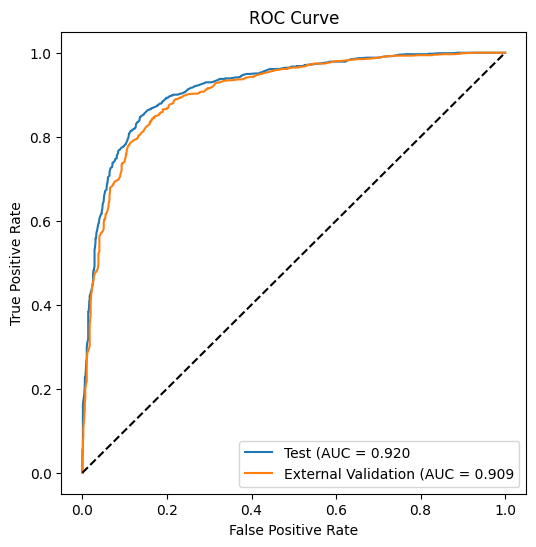

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ROC curves
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
fpr_ext, tpr_ext, _ = roc_curve(y_external, y_prob_external)

plt.figure(figsize=(6,6))

plt.plot(fpr_test, tpr_test,
         label=f"Test (AUC = {roc_auc_score(y_test, y_prob_test):.3f}")

plt.plot(fpr_ext, tpr_ext,
         label=f"External Validation (AUC = {roc_auc_score(y_external, y_prob_external):.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Plot feature importance**

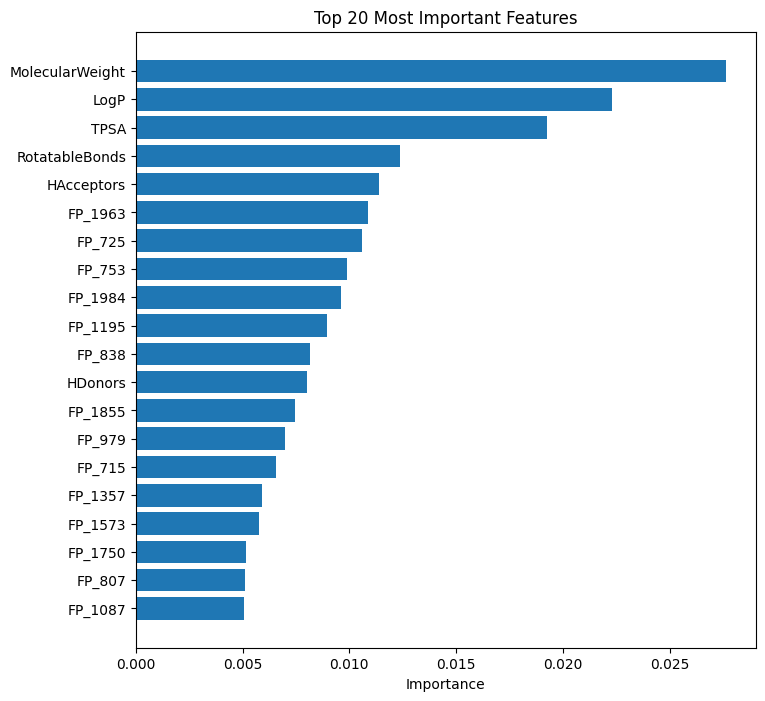

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,8))
plt.barh(
    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]
)
plt.xlabel("Importance")
plt.title("Top 20 Most Important Features")
plt.show()

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Create an output folder**

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/Notebook4_Output", exist_ok=True)

print("Notebook4_Output folder created!")

Notebook4_Output folder created!


**Save the trained model to Google Drive**

In [ ]:
import joblib

joblib.dump(
    rf,
    "/content/drive/MyDrive/Notebook4_Output/RandomForest_model.pkl"
)

print("Model saved successfully to Google Drive!")

Model saved successfully to Google Drive!


In [ ]:
!ls "/content/drive/MyDrive/Notebook4_Output"

ConfusionMatrix_External_RF.png  RandomForest_model.pkl
ConfusionMatrix_Test_RF.png


**Save the confusion matrix**

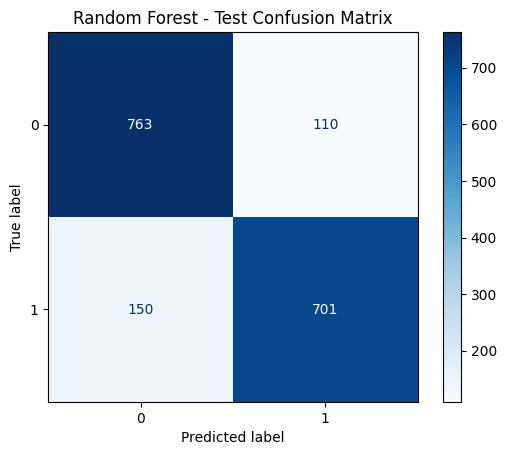

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap="Blues")
plt.title("Random Forest - Test Confusion Matrix")

plt.savefig(
    "/content/drive/MyDrive/Notebook4_Output/ConfusionMatrix_Test_RF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Load the saved model**

In [ ]:
import joblib

rf = joblib.load("RandomForest_model.pkl")

In [ ]:
y_prob = rf.predict_proba(X_test)[:, 1]

**Plot ROC curve**

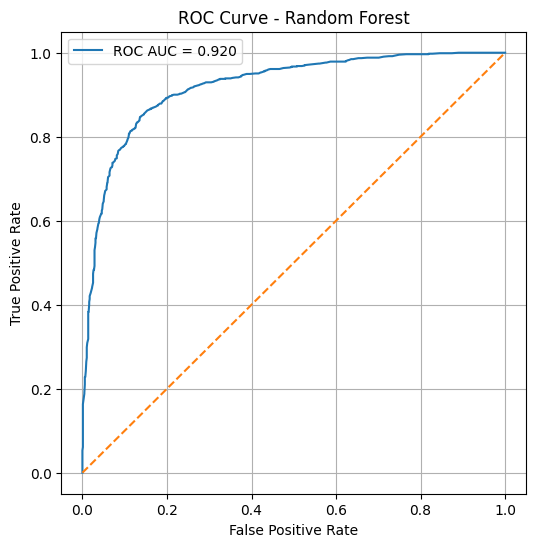

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

**Plot Precision–Recall curve**

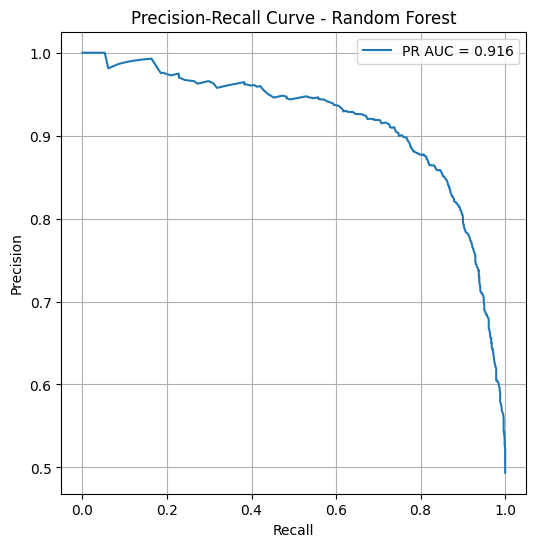

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

**Check the trained model**

In [ ]:
print(type(rf))
print(X_test.shape)
print(y_test.shape)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
(1724, 2054)
(1724,)


**Predict test labels**

In [ ]:
# Predict class labels
y_pred = rf.predict(X_test)

**Generate the classification report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       873
           1       0.86      0.82      0.84       851

    accuracy                           0.85      1724
   macro avg       0.85      0.85      0.85      1724
weighted avg       0.85      0.85      0.85      1724

